In [ ]:
#Nombre: Yupari Figueroa Rosa Isela
#URL del dataset:https://www.kaggle.com/datasets/markmedhat/apple-quality
#Tematica: predicir calidad de manzana
#variables de salida: calidad de manzana bien o malo
#formato:9 columnas 3999 filas

In [ ]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# Modulo de optimización de scipy
from scipy import optimize

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [ ]:
import pandas as pd
#Se utiliza para codificar etiquetas categoricas en forma numerica
from sklearn.preprocessing import LabelEncoder
from datetime import datetime


# Importar libreria para dividir entrenamiento y prueba
from sklearn.model_selection import train_test_split


In [ ]:
# Carga de dataset
data = pd.read_csv('/content/apple_quality.csv')

In [ ]:
display(data)

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good
...,...,...,...,...,...,...,...,...,...
3996,3996.0,-0.293118,1.949253,-0.204020,-0.640196,0.024523,-1.087900,1.854235285,good
3997,3997.0,-2.634515,-2.138247,-2.440461,0.657223,2.199709,4.763859,-1.334611391,bad
3998,3998.0,-4.008004,-1.779337,2.366397,-0.200329,2.161435,0.214488,-2.229719806,good
3999,3999.0,0.278540,-1.715505,0.121217,-1.154075,1.266677,-0.776571,1.599796456,good


In [ ]:
print(data)

        A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
0        0.0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840   
1        1.0 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530   
2        2.0 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033   
3        3.0 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761   
4        4.0  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849   
...      ...       ...       ...        ...          ...        ...       ...   
3996  3996.0 -0.293118  1.949253  -0.204020    -0.640196   0.024523 -1.087900   
3997  3997.0 -2.634515 -2.138247  -2.440461     0.657223   2.199709  4.763859   
3998  3998.0 -4.008004 -1.779337   2.366397    -0.200329   2.161435  0.214488   
3999  3999.0  0.278540 -1.715505   0.121217    -1.154075   1.266677 -0.776571   
4000     NaN       NaN       NaN        NaN          NaN        NaN       NaN   

                           

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB


In [ ]:
#variables categoricas
columnas_categoricas = data.select_dtypes(include=['object']).columns
#variables fechas
columnas_fechas = data.select_dtypes(include=['datetime64']).columns

In [ ]:
#Procesamiento de frases o palabras
for columna in columnas_categoricas:
  le = LabelEncoder()
  data[columna] = le.fit_transform(data[columna])

In [ ]:
#resultado
print(data)

        A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
0        0.0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840   
1        1.0 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530   
2        2.0 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033   
3        3.0 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761   
4        4.0  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849   
...      ...       ...       ...        ...          ...        ...       ...   
3996  3996.0 -0.293118  1.949253  -0.204020    -0.640196   0.024523 -1.087900   
3997  3997.0 -2.634515 -2.138247  -2.440461     0.657223   2.199709  4.763859   
3998  3998.0 -4.008004 -1.779337   2.366397    -0.200329   2.161435  0.214488   
3999  3999.0  0.278540 -1.715505   0.121217    -1.154075   1.266677 -0.776571   
4000     NaN       NaN       NaN        NaN          NaN        NaN       NaN   

      Acidity  Quality  
0 

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   int64  
 8   Quality      4001 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 281.4 KB


In [ ]:
#llenar datos vacios
columnas_especificas = ['A_id', 'Size', 'Weight', 'Sweetness', 'Crunchiness', 'Juiciness','Ripeness']
media_columnas = data[columnas_especificas].mean()
data[columnas_especificas] = data[columnas_especificas].fillna(media_columnas)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4001 non-null   float64
 1   Size         4001 non-null   float64
 2   Weight       4001 non-null   float64
 3   Sweetness    4001 non-null   float64
 4   Crunchiness  4001 non-null   float64
 5   Juiciness    4001 non-null   float64
 6   Ripeness     4001 non-null   float64
 7   Acidity      4001 non-null   int64  
 8   Quality      4001 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 281.4 KB


In [ ]:
# Lectura de Datos
X = data.iloc[:, :8]
y = data.iloc[:, 8]
m = y.size

In [ ]:
print(X)
print('*'*25)
print(y)

        A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
0        0.0 -3.970049 -2.512336   5.346330    -1.012009   1.844900  0.329840   
1        1.0 -1.195217 -2.839257   3.664059     1.588232   0.853286  0.867530   
2        2.0 -0.292024 -1.351282  -1.738429    -0.342616   2.838636 -0.038033   
3        3.0 -0.657196 -2.271627   1.324874    -0.097875   3.637970 -3.413761   
4        4.0  1.364217 -1.296612  -0.384658    -0.553006   3.030874 -1.303849   
...      ...       ...       ...        ...          ...        ...       ...   
3996  3996.0 -0.293118  1.949253  -0.204020    -0.640196   0.024523 -1.087900   
3997  3997.0 -2.634515 -2.138247  -2.440461     0.657223   2.199709  4.763859   
3998  3998.0 -4.008004 -1.779337   2.366397    -0.200329   2.161435  0.214488   
3999  3999.0  0.278540 -1.715505   0.121217    -1.154075   1.266677 -0.776571   
4000  1999.5 -0.503015 -0.989547  -0.470479     0.985478   0.512118  0.498277   

      Acidity  
0         3

In [ ]:
# Funcion train_test_split, que recibe X y y, test_size es el tamaño de prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [ ]:
print("Datos entrenamiento> ")
print(X_train)
print('-'*40)
print(y_train)

Datos entrenamiento> 
        A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
2325  2325.0 -1.447189 -1.675930  -0.464820     2.638307  -2.620991  3.498612   
1792  1792.0 -0.590261 -0.744094  -1.957695     1.096279   2.137061  2.189599   
3809  3809.0  2.905225 -2.220216  -3.041612     2.024207   0.939727  0.768177   
412    412.0 -0.704063 -5.227087   4.445395     3.243947   1.186647  2.484259   
1883  1883.0 -3.566782  2.148825  -0.152948    -0.821547   1.402363 -0.436948   
...      ...       ...       ...        ...          ...        ...       ...   
1921  1921.0 -3.381069 -2.621758   3.187340     2.043881   3.062443 -0.363866   
709    709.0  0.028746  1.186992   0.666876     2.193248  -1.440550 -3.155569   
2487  2487.0  0.782754 -1.548183  -0.131064     2.578626   1.320529  1.412758   
174    174.0  0.268230 -1.157147   2.571969    -0.329585  -1.242082  2.226250   
1146  1146.0 -4.120193 -1.749556   1.305360     1.107399  -0.195565  0.488467   

     

In [ ]:
print("Datos prueba> ")
print(X_test)
print('-'*40)
print(y_test)

Datos prueba> 
        A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  Ripeness  \
3157  3157.0  1.625461 -1.534990  -5.016761     0.309944   1.110964  2.913674   
2560  2560.0 -2.002109  0.914239  -1.212155     0.377443  -0.412552  1.292215   
15      15.0 -2.659887 -2.795684   4.230404     0.697550   2.180911 -0.088775   
1872  1872.0  1.220269 -1.813115  -2.825257     0.593482   2.364036  2.256645   
491    491.0 -0.209518  0.874576  -2.954284     3.103599  -0.599039 -1.187981   
...      ...       ...       ...        ...          ...        ...       ...   
2836  2836.0 -3.549489 -0.976954  -2.239477     0.001590  -2.469424  2.354201   
3686  3686.0 -0.950542 -0.878033  -1.381008     2.264994  -2.574356 -1.511089   
3080  3080.0 -5.087387  5.014002  -1.652091    -1.025455   1.460314 -1.994076   
997    997.0  2.789451 -0.350118  -4.032199    -0.075977   2.113071  0.115447   
2590  2590.0  0.508201 -0.564488  -2.599425     1.696247   0.198400  0.584408   

      Acidit

In [ ]:
def  featureNormalize(X):
    X_norm = X_train.copy()
    mu = np.zeros(X_train.shape[1])
    sigma = np.zeros(X_train.shape[1])

    mu = np.mean(X_train, axis = 0)
    sigma = np.std(X_train, axis = 0)
    X_norm = (X_train - mu) / sigma

    return X_norm, mu, sigma

In [ ]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X_train)

print('Media calculada:\n',mu)
print('Desviación estandar calculada:\n',sigma)
print('Matriz con valores normalizados:\n',X_norm)

Media calculada:
 A_id           1994.724219
Size             -0.509478
Weight           -1.010869
Sweetness        -0.435487
Crunchiness       0.990510
Juiciness         0.515650
Ripeness          0.492231
Acidity        1979.735312
dtype: float64
Desviación estandar calculada:
 A_id           1151.253487
Size              1.930185
Weight            1.585905
Sweetness         1.946632
Crunchiness       1.403823
Juiciness         1.929643
Ripeness          1.877160
Acidity        1150.012855
dtype: float64
Matriz con valores normalizados:
           A_id      Size    Weight  Sweetness  Crunchiness  Juiciness  \
2325  0.286884 -0.485814 -0.419358  -0.015068     1.173793  -1.625503   
1792 -0.176090 -0.041853  0.168216  -0.781970     0.075344   0.840264   
3809  1.575913  1.769107 -0.762559  -1.338786     0.736345   0.219770   
412  -1.374783 -0.100812 -2.658556   2.507347     1.605215   0.347731   
1883 -0.097046 -1.583944  1.992360   0.145142    -1.290802   0.459522   
...        ...  

In [ ]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [ ]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X], axis=1)

In [ ]:
# Configurar la matriz adecuadamente, y agregar una columna de unos
m = X_train.shape[0]
X_train = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [ ]:
def calcularCosto(theta, X_train, y_train):
    # Inicializar algunos valores utiles
    m = y_train.size  # numero de ejemplos de entrenamiento
    #epsilon = 1e-8

    J = 0
    h = sigmoid(X_train.dot(theta.T))
    J = (1 / m) * np.sum(-y_train.dot(np.log(h)) - (1 - y_train).dot(np.log(1 - h)))

    return J

In [ ]:
def descensoGradiente(theta, X_train, y_train, alpha, num_iters):
    # Inicializa algunos valores
    m = y_train.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X_train.dot(theta.T))
        theta = theta - (alpha / m) * (h - y_train).dot(X_train)

        J_history.append(calcularCosto(theta, X_train, y_train))
    return theta, J_history

In [ ]:
primera_fila = X_test.iloc[0]

# Imprimir la primera fila en forma de fila
for valor in primera_fila:
    print(valor, end=',')

3157.0,1.625461266,-1.534990098,-5.016761418,0.309943529,1.110963794,2.913673713,561.0,

theta calculado por el descenso por el gradiente: [-0.00569608  0.04428441  0.9908475   0.25425482  0.87566449 -0.02084323
  0.76670804 -0.31567626 -0.41445123]
El resultado muestra la calidad de una manzana:0


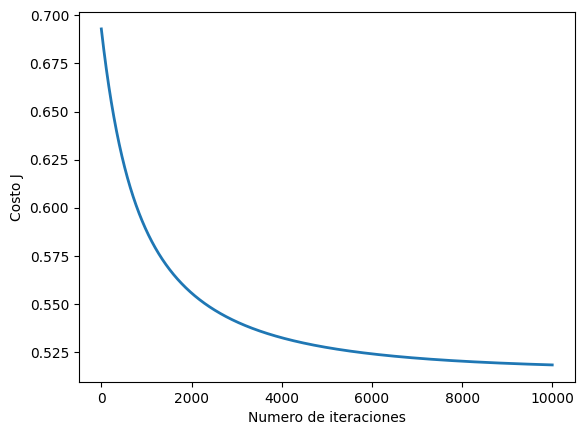

In [ ]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(9)
theta, J_history = descensoGradiente(theta, X_train, y_train, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

X_array = [1, 3157.0, 1.625461266, -1.534990098, -5.016761418, 0.309943529, 1.110963794, 2.913673713, 561.0,]
calidad= sigmoid(np.dot(X_array, theta))

print('El resultado muestra la calidad de una manzana:{:.0f}'.format(calidad))

In [ ]:
print(X_test.shape)

(801, 8)


In [ ]:
m = X_test.shape[0]
print(m)

801


In [ ]:
n=X_test.shape[1]
X_test = np.concatenate([np.ones((m, 1)), X_test], axis=1)

In [ ]:
def costFunction(theta, X, y):
    # Inicializar algunos valores utiles
    m = y_test.size  # numero de ejemplos de entrenamiento
    #Se define una pequeña cantidad epsilon para evitar problemas de logaritmo de cero en el cálculo de la función de costo
    epsilon = 1e-8

    J = 0
    grad = np.zeros(theta.shape)

    h = sigmoid(X_test.dot(theta.T))

    J = (1 / m) * np.sum(-y_test.dot(np.log(h+epsilon)) - (1 - y_test).dot(np.log(1 - h+epsilon)))
    grad = (1 / m) * (h - y_test).dot(X_test)

    return J, grad

In [ ]:
# Inicializacion de parametros de ajuste
initial_theta = np.zeros(n+1)
print(initial_theta)
cost, grad = costFunction(initial_theta, X, y)

print('Costo en theta inicial (zeros): {:.3f}'.format(cost))
print('Gradiente en theta inicial (zeros):')
print('\t[{:.2f}, {:.2f}, {:.2f},{:.2f}, {:.2f}, {:.2f}, {:.2f},{:.2f}, {:.2f}]'.format(*grad))

[0. 0. 0. 0. 0. 0. 0. 0. 0.]
Costo en theta inicial (zeros): 0.693
Gradiente en theta inicial (zeros):
	[0.01, 46.82, -0.23,-0.04, -0.24, 0.04, -0.16,0.25, 40.25]


In [ ]:
# Calcula y muestra el costo y el gradiente con valores de theta diferentes a cero

test_theta = np.array([-0.5, 0.8, -1.2, 0.3, -0.7, 1.0, -1.5, 0.2, 1.2])

print(test_theta)
cost, grad = costFunction(test_theta, X_test, y_test)

print('Costo en theta prueba: {:.2f}'.format(cost))

print('Gradiente en theta prueba:')
print('\t[{:.2f}, {:.2f}, {:.2f},{:.2f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}]'.format(*grad))

[-0.5  0.8 -1.2  0.3 -0.7  1.  -1.5  0.2  1.2]
Costo en theta prueba: 9.45
Gradiente en theta prueba:
	[0.51, 1056.11, -0.46,-0.49, -0.55, 0.52, 0.08, 0.51, 1080.73]


In [ ]:
# Esta línea define un diccionario options
# que contiene las opciones de configuración para el algoritmo de optimización
options= {'maxiter': 1000}

# options=options: Las opciones de configuración para el algoritmo de optimización.
res = optimize.minimize(costFunction,initial_theta,(X_test, y_test),jac=True,method='TNC',options=options)

# Esta línea extrae el valor del costo óptimo del objeto res y lo guarda en la variable cost
cost = res.fun

# Esta línea extrae los valores óptimos de los parámetros de ajuste (theta) del objeto res y
# los guarda en la variable theta
theta = res.x

# Imprimir theta en la pantalla
print('Costo con un valor de theta encontrado por optimize.minimize: {:.3f}'.format(cost))


print('theta:')
print('\t[{:.2f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}, {:.2f}]'.format(*theta))

Costo con un valor de theta encontrado por optimize.minimize: 0.545
theta:
	[1.55, -0.00, 0.56, 0.28, 0.54, -0.07, 0.29, -0.14, -0.00]


<ipython-input-38-14c5adb679ae>:6: OptimizeWarning: Unknown solver options: maxiter
  res = optimize.minimize(costFunction,initial_theta,(X_test, y_test),jac=True,method='TNC',options=options)


In [ ]:
def predict(theta, X_test):
    #devuelve el tamaño del primer eje de la matriz
    m = X_test.shape[0] # Numero de ejemplo de entrenamiento
    #Esta línea inicializa un vector p de tamaño m con ceros
    p = np.zeros(m)
    #Esta línea realiza las predicciones utilizando la función sigmoide y el producto punto entre X_test y theta.T
    p = np.round(sigmoid(X_test.dot(theta.T)))
    return p

In [ ]:
print(X_test.shape)

(801, 9)


In [ ]:
print(theta.shape)

(9,)


In [ ]:
prob = sigmoid(np.dot([1, 157.0, 1.625461266, -1.534990098, -5.016761418, 0.309943529, 1.110963794, 2.913673713, 561.0], theta))
print('Con estos datos la prediccion es: {:.0f}'.format(prob))

p = predict(theta, X_test)
# Esta línea calcula la precisión en el conjunto de prueba comparando las predicciones p
# con las etiquetas reales y_test. La función np.mean(p == y_test) calcula la proporción
# de predicciones correctas, y se multiplica por 100 para obtener el porcentaje de precisión.
print('Precisión de entrenamiento: {:.2f} %'.format(np.mean(p == y_test) * 100))

Con estos datos la prediccion es: 0
Precisión de entrenamiento: 72.78 %
